# 05 - Extraction de la trajectoire de l’objet

Dans cette étape, nous allons utiliser les points suivis par Lucas-Kanade pour extraire la trajectoire globale de l’objet dans la séquence d’images. L’idée est de calculer, pour chaque frame, une position représentative de l’objet à partir des points caractéristiques suivis.

Comme nous travaillons sur un objet unique, nous pouvons représenter sa position globale par le centre moyen des points suivis. En stockant ce centre pour chaque frame, nous obtenons la trajectoire de l’objet.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour lire les images, suivre les points, visualiser les résultats et sauvegarder la trajectoire.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")

try:
    from src.preprocessing import preprocess_image
    from src.detection import read_groundtruth, get_initial_bbox, detect_features_in_roi
    from src.optical_flow import compute_lucas_kanade
    print("Fonctions importées depuis le dossier src.")
except ImportError:
    preprocess_image = None
    read_groundtruth = None
    get_initial_bbox = None
    detect_features_in_roi = None
    compute_lucas_kanade = None
    print("Import impossible : des versions simples seront utilisées dans le notebook si nécessaire.")

Fonctions importées depuis le dossier src.


## 2. Définition des chemins du dataset

Nous définissons les chemins du dataset et les dossiers de résultats. Les graphes et images générés seront sauvegardés dans le dossier `results`.

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
groundtruth_path = dataset_path / "groundtruth.txt"

results_path = Path("../results")
plots_path = results_path / "plots"
frames_output_path = results_path / "frames_output"

plots_path.mkdir(parents=True, exist_ok=True)
frames_output_path.mkdir(parents=True, exist_ok=True)

print("Chemin du dataset :", dataset_path)
print("Le dossier img existe :", img_path.exists())
print("Le fichier groundtruth.txt existe :", groundtruth_path.exists())

image_extensions = [".jpg", ".png", ".jpeg"]

if img_path.exists():
    image_files = sorted([
        file for file in img_path.iterdir()
        if file.suffix.lower() in image_extensions
    ])
else:
    image_files = []
    print("Attention : le dossier img est introuvable.")

print("Nombre total d'images :", len(image_files))
print("Cinq premières images :")
for image_file in image_files[:5]:
    print("-", image_file.name)

Chemin du dataset : ..\data\car\car-11
Le dossier img existe : True
Le fichier groundtruth.txt existe : True
Nombre total d'images : 1661
Cinq premières images :
- 00000001.jpg
- 00000002.jpg
- 00000003.jpg
- 00000004.jpg
- 00000005.jpg


## 3. Chargement du groundtruth et de la première frame

Nous chargeons le fichier `groundtruth.txt` et la première image. La première bounding box servira à initialiser l’objet à suivre.

,x,y,w,h
0,543,305,202,91
1,544,301,199,90
2,544,301,197,89
3,544,300,196,91
4,543,302,197,89


Bounding box initiale : (543, 305, 202, 91)


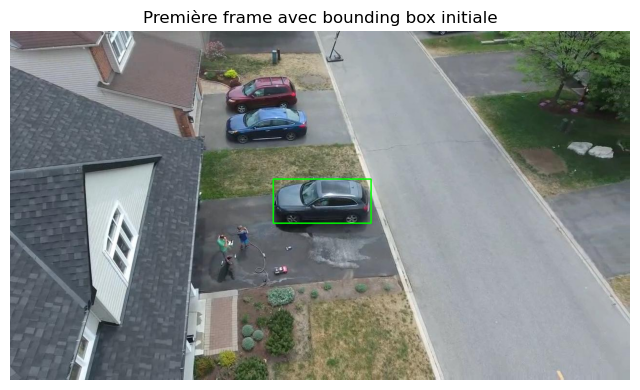

In [3]:
groundtruth = pd.DataFrame(columns=["x", "y", "w", "h"])
initial_bbox = None
first_image_bgr = None

if read_groundtruth is not None:
    groundtruth = read_groundtruth(groundtruth_path)
elif groundtruth_path.exists() and groundtruth_path.stat().st_size > 0:
    groundtruth = pd.read_csv(groundtruth_path, header=None, sep=r"[,\s]+", engine="python")
    groundtruth = groundtruth.iloc[:, :4]
    groundtruth.columns = ["x", "y", "w", "h"]
    groundtruth = groundtruth.astype(int)

if len(groundtruth) > 0:
    if get_initial_bbox is not None:
        initial_bbox = get_initial_bbox(groundtruth)
    else:
        x, y, w, h = groundtruth.iloc[0]
        initial_bbox = (int(x), int(y), int(w), int(h))

    display(groundtruth.head())
    print("Bounding box initiale :", initial_bbox)
else:
    print("Aucune annotation groundtruth n'a été trouvée.")

if len(image_files) > 0:
    first_image_bgr = cv2.imread(str(image_files[0]))

if first_image_bgr is not None and initial_bbox is not None:
    x, y, w, h = initial_bbox
    image_with_bbox = first_image_bgr.copy()
    cv2.rectangle(image_with_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)

    image_with_bbox_rgb = cv2.cvtColor(image_with_bbox, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(image_with_bbox_rgb)
    plt.title("Première frame avec bounding box initiale")
    plt.axis("off")
    plt.show()
else:
    print("Impossible d'afficher la première frame avec la bounding box.")

La première bounding box permet d’initialiser l’objet que nous voulons suivre. Elle définit la région où les points caractéristiques seront détectés.

## 4. Prétraitement de la première frame et initialisation des points

Nous prétraitons la première frame, puis nous détectons les points caractéristiques dans la ROI de l’objet.

Nombre de points initiaux détectés : 80


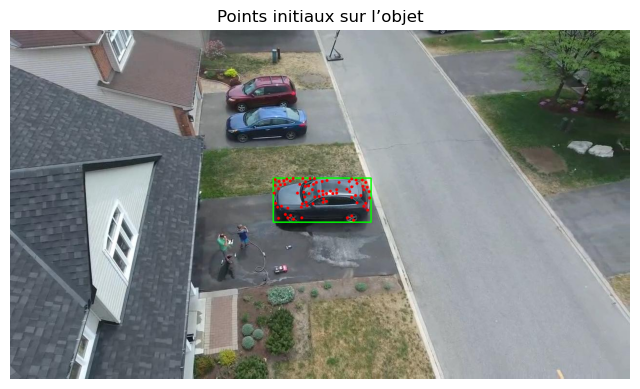

In [4]:
if preprocess_image is None:
    def preprocess_image(image_bgr):
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        preprocessed = cv2.GaussianBlur(enhanced, (5, 5), 0)
        return preprocessed

    print("Version simple de preprocess_image définie dans le notebook.")

first_gray = None
initial_points = None

if first_image_bgr is not None and initial_bbox is not None:
    first_gray = preprocess_image(first_image_bgr)
    x, y, w, h = initial_bbox
    roi_gray = first_gray[y:y + h, x:x + w]

    initial_points = cv2.goodFeaturesToTrack(
        roi_gray,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    if initial_points is not None:
        initial_points = initial_points.astype(np.float32)
        initial_points[:, 0, 0] += x
        initial_points[:, 0, 1] += y
        print("Nombre de points initiaux détectés :", len(initial_points))
    else:
        print("Aucun point initial n'a été détecté dans la ROI.")

    image_points = first_image_bgr.copy()
    cv2.rectangle(image_points, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if initial_points is not None:
        for point in initial_points:
            px, py = point.ravel().astype(int)
            cv2.circle(image_points, (px, py), 3, (0, 0, 255), -1)

    image_points_rgb = cv2.cvtColor(image_points, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(image_points_rgb)
    plt.title("Points initiaux sur l’objet")
    plt.axis("off")
    plt.show()
else:
    print("Impossible de prétraiter la première frame ou de détecter les points.")

Ces points initiaux représentent les détails de l’objet que nous allons suivre dans les images suivantes.

## 5. Principe de calcul de la trajectoire

Pour chaque frame, nous allons :

1. suivre les points de l’objet avec Lucas-Kanade ;
2. garder uniquement les points suivis correctement ;
3. calculer le centre moyen des points ;
4. ajouter ce centre à une liste appelée `trajectory`.

Formule simple :

`centre_x = moyenne des coordonnées x des points suivis`  
`centre_y = moyenne des coordonnées y des points suivis`

Ce centre représente la position globale de l’objet dans la frame.

## 6. Extraction de la trajectoire sur plusieurs frames

Nous suivons les points frame par frame sur les 100 premières images. Si le nombre de points suivis devient trop faible, nous utilisons la bounding box du groundtruth pour réinitialiser les points. Cette réinitialisation sert uniquement à éviter une perte complète du suivi.

In [5]:
def compute_center_from_points(points):
    if points is None or len(points) == 0:
        return None

    points_array = np.asarray(points).reshape(-1, 2)
    center_x = float(np.mean(points_array[:, 0]))
    center_y = float(np.mean(points_array[:, 1]))
    return center_x, center_y


def detect_points_from_bbox(gray_image, bbox):
    x, y, w, h = bbox
    roi_gray = gray_image[y:y + h, x:x + w]

    points = cv2.goodFeaturesToTrack(
        roi_gray,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    if points is None:
        return None

    points = points.astype(np.float32)
    points[:, 0, 0] += x
    points[:, 0, 1] += y
    return points


trajectory = []
trajectory_frames = []
tracked_points_count = []
last_processed_frame = 0

max_frames = min(100, len(image_files))

lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

if first_gray is not None and initial_points is not None and max_frames > 0:
    x, y, w, h = initial_bbox
    initial_center = compute_center_from_points(initial_points)

    if initial_center is None:
        initial_center = (x + w / 2, y + h / 2)

    trajectory.append(initial_center)
    trajectory_frames.append(0)
    tracked_points_count.append(len(initial_points))

    prev_gray = first_gray.copy()
    points = initial_points.copy()

    for frame_index in range(1, max_frames):
        current_image_bgr = cv2.imread(str(image_files[frame_index]))

        if current_image_bgr is None:
            print(f"Frame {frame_index} : image non chargée")
            break

        current_gray = preprocess_image(current_image_bgr)
        new_points, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray,
            current_gray,
            points,
            None,
            **lk_params
        )

        if new_points is not None and status is not None:
            good_points = new_points[status.ravel() == 1].reshape(-1, 2)
        else:
            good_points = np.empty((0, 2), dtype=np.float32)

        if len(good_points) >= 5:
            center = compute_center_from_points(good_points)
            trajectory.append(center)
            trajectory_frames.append(frame_index)
            tracked_points_count.append(len(good_points))

            points = good_points.reshape(-1, 1, 2).astype(np.float32)
            prev_gray = current_gray
        else:
            print(f"Frame {frame_index} : suivi faible avec {len(good_points)} point(s). Réinitialisation avec groundtruth.")

            if frame_index < len(groundtruth):
                bbox_values = groundtruth.iloc[frame_index]
                bbox = tuple(bbox_values.astype(int))
                x, y, w, h = bbox
                center = (x + w / 2, y + h / 2)

                new_detected_points = detect_points_from_bbox(current_gray, bbox)

                trajectory.append(center)
                trajectory_frames.append(frame_index)
                tracked_points_count.append(0 if new_detected_points is None else len(new_detected_points))

                if new_detected_points is not None and len(new_detected_points) >= 5:
                    points = new_detected_points
                    prev_gray = current_gray
                else:
                    print("La réinitialisation n'a pas trouvé assez de points. Nous arrêtons le suivi.")
                    break
            else:
                print("Groundtruth indisponible pour cette frame. Nous gardons la dernière position connue et nous arrêtons.")
                trajectory.append(trajectory[-1])
                trajectory_frames.append(frame_index)
                tracked_points_count.append(0)
                break

        last_processed_frame = frame_index

    print("Nombre de positions dans trajectory :", len(trajectory))
    print("Premières positions :", trajectory[:5])
    print("Nombre moyen de points suivis :", np.mean(tracked_points_count))
else:
    print("Impossible d'extraire la trajectoire car les données initiales manquent.")

Nombre de positions dans trajectory : 100
Premières positions : [(639.9874877929688, 337.9624938964844), (639.3473510742188, 337.92950439453125), (638.60205078125, 337.76708984375), (637.8245849609375, 337.64990234375), (637.0502319335938, 337.47198486328125)]
Nombre moyen de points suivis : 80.0


Nous obtenons ici une liste de positions représentant le déplacement global de l’objet dans la séquence. La réinitialisation avec le groundtruth permet de garder un suivi stable lorsque certains points sont perdus.

## 7. Visualisation de la trajectoire sur une image

Nous dessinons la trajectoire sur une frame de référence, ici la dernière frame traitée. Les lignes relient les centres successifs de l’objet.

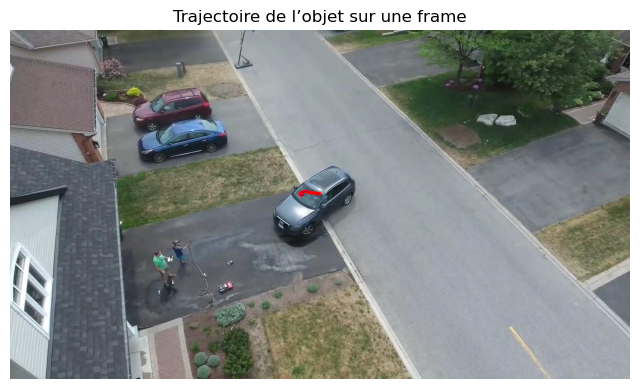

Image sauvegardée dans : ..\results\plots\trajectory_on_frame.png


In [6]:
trajectory_on_frame_path = plots_path / "trajectory_on_frame.png"

if len(trajectory) > 0 and len(image_files) > 0:
    reference_index = min(last_processed_frame, len(image_files) - 1)
    reference_image_bgr = cv2.imread(str(image_files[reference_index]))

    if reference_image_bgr is not None:
        image_with_trajectory = reference_image_bgr.copy()
        trajectory_points = np.asarray(trajectory, dtype=np.int32)

        for index, point in enumerate(trajectory_points):
            px, py = point
            cv2.circle(image_with_trajectory, (px, py), 3, (0, 0, 255), -1)

            if index > 0:
                prev_x, prev_y = trajectory_points[index - 1]
                cv2.line(image_with_trajectory, (prev_x, prev_y), (px, py), (255, 0, 0), 2)

        cv2.imwrite(str(trajectory_on_frame_path), image_with_trajectory)

        image_with_trajectory_rgb = cv2.cvtColor(image_with_trajectory, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 5))
        plt.imshow(image_with_trajectory_rgb)
        plt.title("Trajectoire de l’objet sur une frame")
        plt.axis("off")
        plt.show()

        print("Image sauvegardée dans :", trajectory_on_frame_path)
    else:
        print("La frame de référence n'a pas pu être chargée.")
else:
    print("Impossible de visualiser la trajectoire car elle est vide.")

La trajectoire dessinée sur l’image montre le chemin suivi par l’objet dans la séquence. Elle donne une visualisation directe du mouvement global.

## 8. Visualisation de la trajectoire dans un repère 2D

Nous traçons maintenant la trajectoire dans le plan image. L’axe `x` représente la position horizontale et l’axe `y` représente la position verticale.

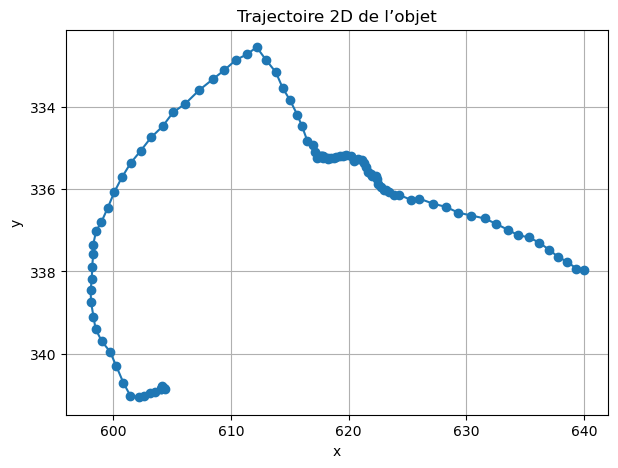

Graphe sauvegardé dans : ..\results\plots\trajectory_2d.png


In [7]:
trajectory_2d_path = plots_path / "trajectory_2d.png"

if len(trajectory) > 0:
    trajectory_array = np.asarray(trajectory)

    plt.figure(figsize=(7, 5))
    plt.plot(trajectory_array[:, 0], trajectory_array[:, 1], marker="o")
    plt.gca().invert_yaxis()
    plt.title("Trajectoire 2D de l’objet")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.savefig(trajectory_2d_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", trajectory_2d_path)
else:
    print("Impossible de tracer la trajectoire 2D car la trajectoire est vide.")

Ce graphe représente la trajectoire de l’objet dans le plan image. L’axe horizontal correspond à x et l’axe vertical correspond à y.

## 9. Évolution des coordonnées x et y au cours du temps

Nous traçons les coordonnées `x` et `y` en fonction du numéro de frame. Cela nous permet d’observer comment la position de l’objet évolue au cours du temps.

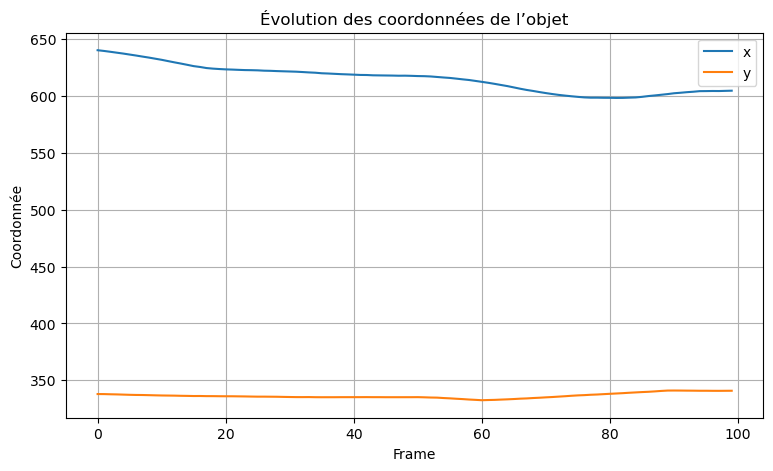

Graphe sauvegardé dans : ..\results\plots\coordinates_over_time.png


In [8]:
coordinates_over_time_path = plots_path / "coordinates_over_time.png"

if len(trajectory) > 0:
    trajectory_array = np.asarray(trajectory)

    plt.figure(figsize=(9, 5))
    plt.plot(trajectory_frames, trajectory_array[:, 0], label="x")
    plt.plot(trajectory_frames, trajectory_array[:, 1], label="y")
    plt.title("Évolution des coordonnées de l’objet")
    plt.xlabel("Frame")
    plt.ylabel("Coordonnée")
    plt.legend()
    plt.grid(True)
    plt.savefig(coordinates_over_time_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", coordinates_over_time_path)
else:
    print("Impossible de tracer les coordonnées car la trajectoire est vide.")

Ces courbes permettent d’observer comment les coordonnées de l’objet évoluent au cours du temps. Une variation régulière indique un mouvement relativement stable.

## 10. Sauvegarde de la trajectoire

Nous sauvegardons la trajectoire dans un fichier CSV. Ce fichier sera utilisé dans l’étape suivante pour analyser la vitesse et la direction.

In [9]:
trajectory_csv_path = results_path / "trajectory.csv"

if len(trajectory) > 0:
    trajectory_array = np.asarray(trajectory)

    trajectory_df = pd.DataFrame({
        "frame": trajectory_frames,
        "x": trajectory_array[:, 0],
        "y": trajectory_array[:, 1],
        "tracked_points": tracked_points_count
    })

    trajectory_df.to_csv(trajectory_csv_path, index=False)
    display(trajectory_df.head())
    print("Trajectoire sauvegardée dans :", trajectory_csv_path)
else:
    trajectory_df = pd.DataFrame(columns=["frame", "x", "y", "tracked_points"])
    print("Aucune trajectoire à sauvegarder.")

,frame,x,y,tracked_points
0,0,639.987488,337.962494,80
1,1,639.347351,337.929504,80
2,2,638.602051,337.767090,80
3,3,637.824585,337.649902,80
4,4,637.050232,337.471985,80


Trajectoire sauvegardée dans : ..\results\trajectory.csv


La trajectoire est sauvegardée dans un fichier CSV afin de pouvoir être utilisée dans l’étape suivante pour calculer la vitesse et la direction du mouvement.

## 11. Création de fonctions simples de trajectoire

Nous créons quelques fonctions simples pour réutiliser les opérations principales : calcul du centre, ajout à la trajectoire et sauvegarde du fichier CSV.

In [10]:
def compute_object_center(points):
    """
    Calcule le centre moyen des points suivis.
    """
    if points is None or len(points) == 0:
        return None

    points_array = np.asarray(points).reshape(-1, 2)
    center_x = float(np.mean(points_array[:, 0]))
    center_y = float(np.mean(points_array[:, 1]))
    return center_x, center_y


def update_trajectory(trajectory, center):
    """
    Ajoute une nouvelle position à la trajectoire.
    """
    if center is not None:
        trajectory.append(center)
    return trajectory


def save_trajectory(trajectory_df, output_path):
    """
    Sauvegarde la trajectoire dans un fichier CSV.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    trajectory_df.to_csv(output_path, index=False)

Nous testons brièvement ces fonctions avec les points initiaux et la trajectoire déjà calculée.

In [11]:
test_trajectory = []
test_center = compute_object_center(initial_points)
test_trajectory = update_trajectory(test_trajectory, test_center)

print("Centre de test :", test_center)
print("Trajectoire de test :", test_trajectory)

if len(trajectory_df) > 0:
    save_trajectory(trajectory_df, trajectory_csv_path)
    print("Test de sauvegarde effectué avec :", trajectory_csv_path)

Centre de test : (639.9874877929688, 337.9624938964844)
Trajectoire de test : [(639.9874877929688, 337.9624938964844)]
Test de sauvegarde effectué avec : ..\results\trajectory.csv


## 12. Conclusion de l’étape d’extraction de trajectoire

Dans cette étape, nous avons extrait la trajectoire globale de l’objet à partir des points suivis par Lucas-Kanade. Pour chaque frame, nous avons calculé une position représentative de l’objet en utilisant le centre moyen des points suivis. Cette trajectoire a été visualisée et sauvegardée dans un fichier CSV. Dans l’étape suivante, nous utiliserons cette trajectoire pour analyser la vitesse et la direction du mouvement.

Nous nous arrêtons ici : nous n’avons pas encore fait l’analyse complète de la vitesse ni de la direction.